<a href="https://colab.research.google.com/github/Aaarin12/Pheno12/blob/main/Flowering_stage_MGP_RT_DETR_Detect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!nvidia-smi

Mon Jun 15 08:23:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   45C    P8             13W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!pip install ultralytics

In [4]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
Setup complete ✅ (12 CPUs, 53.0 GB RAM, 47.3/235.7 GB disk)


In [5]:
from ultralytics import YOLO
from IPython.display import display, Image

In [6]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="Z7f2dmvyVE8aCnZs5yez")
project = rf.workspace("image-analysis-0mduj").project("mgp-flowering")
version = project.version(3)
dataset = version.download("yolov5")


loading Roboflow workspace...
loading Roboflow project...


In [7]:
dataset.location

'/content/MGP-flowering-3'

In [8]:
!yolo task=detect mode=train data={dataset.location}/data.yaml model="rtdetr-l.pt" epochs=35 imgsz=640

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/MGP-flowering-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

In [9]:
from IPython.display import display, Image

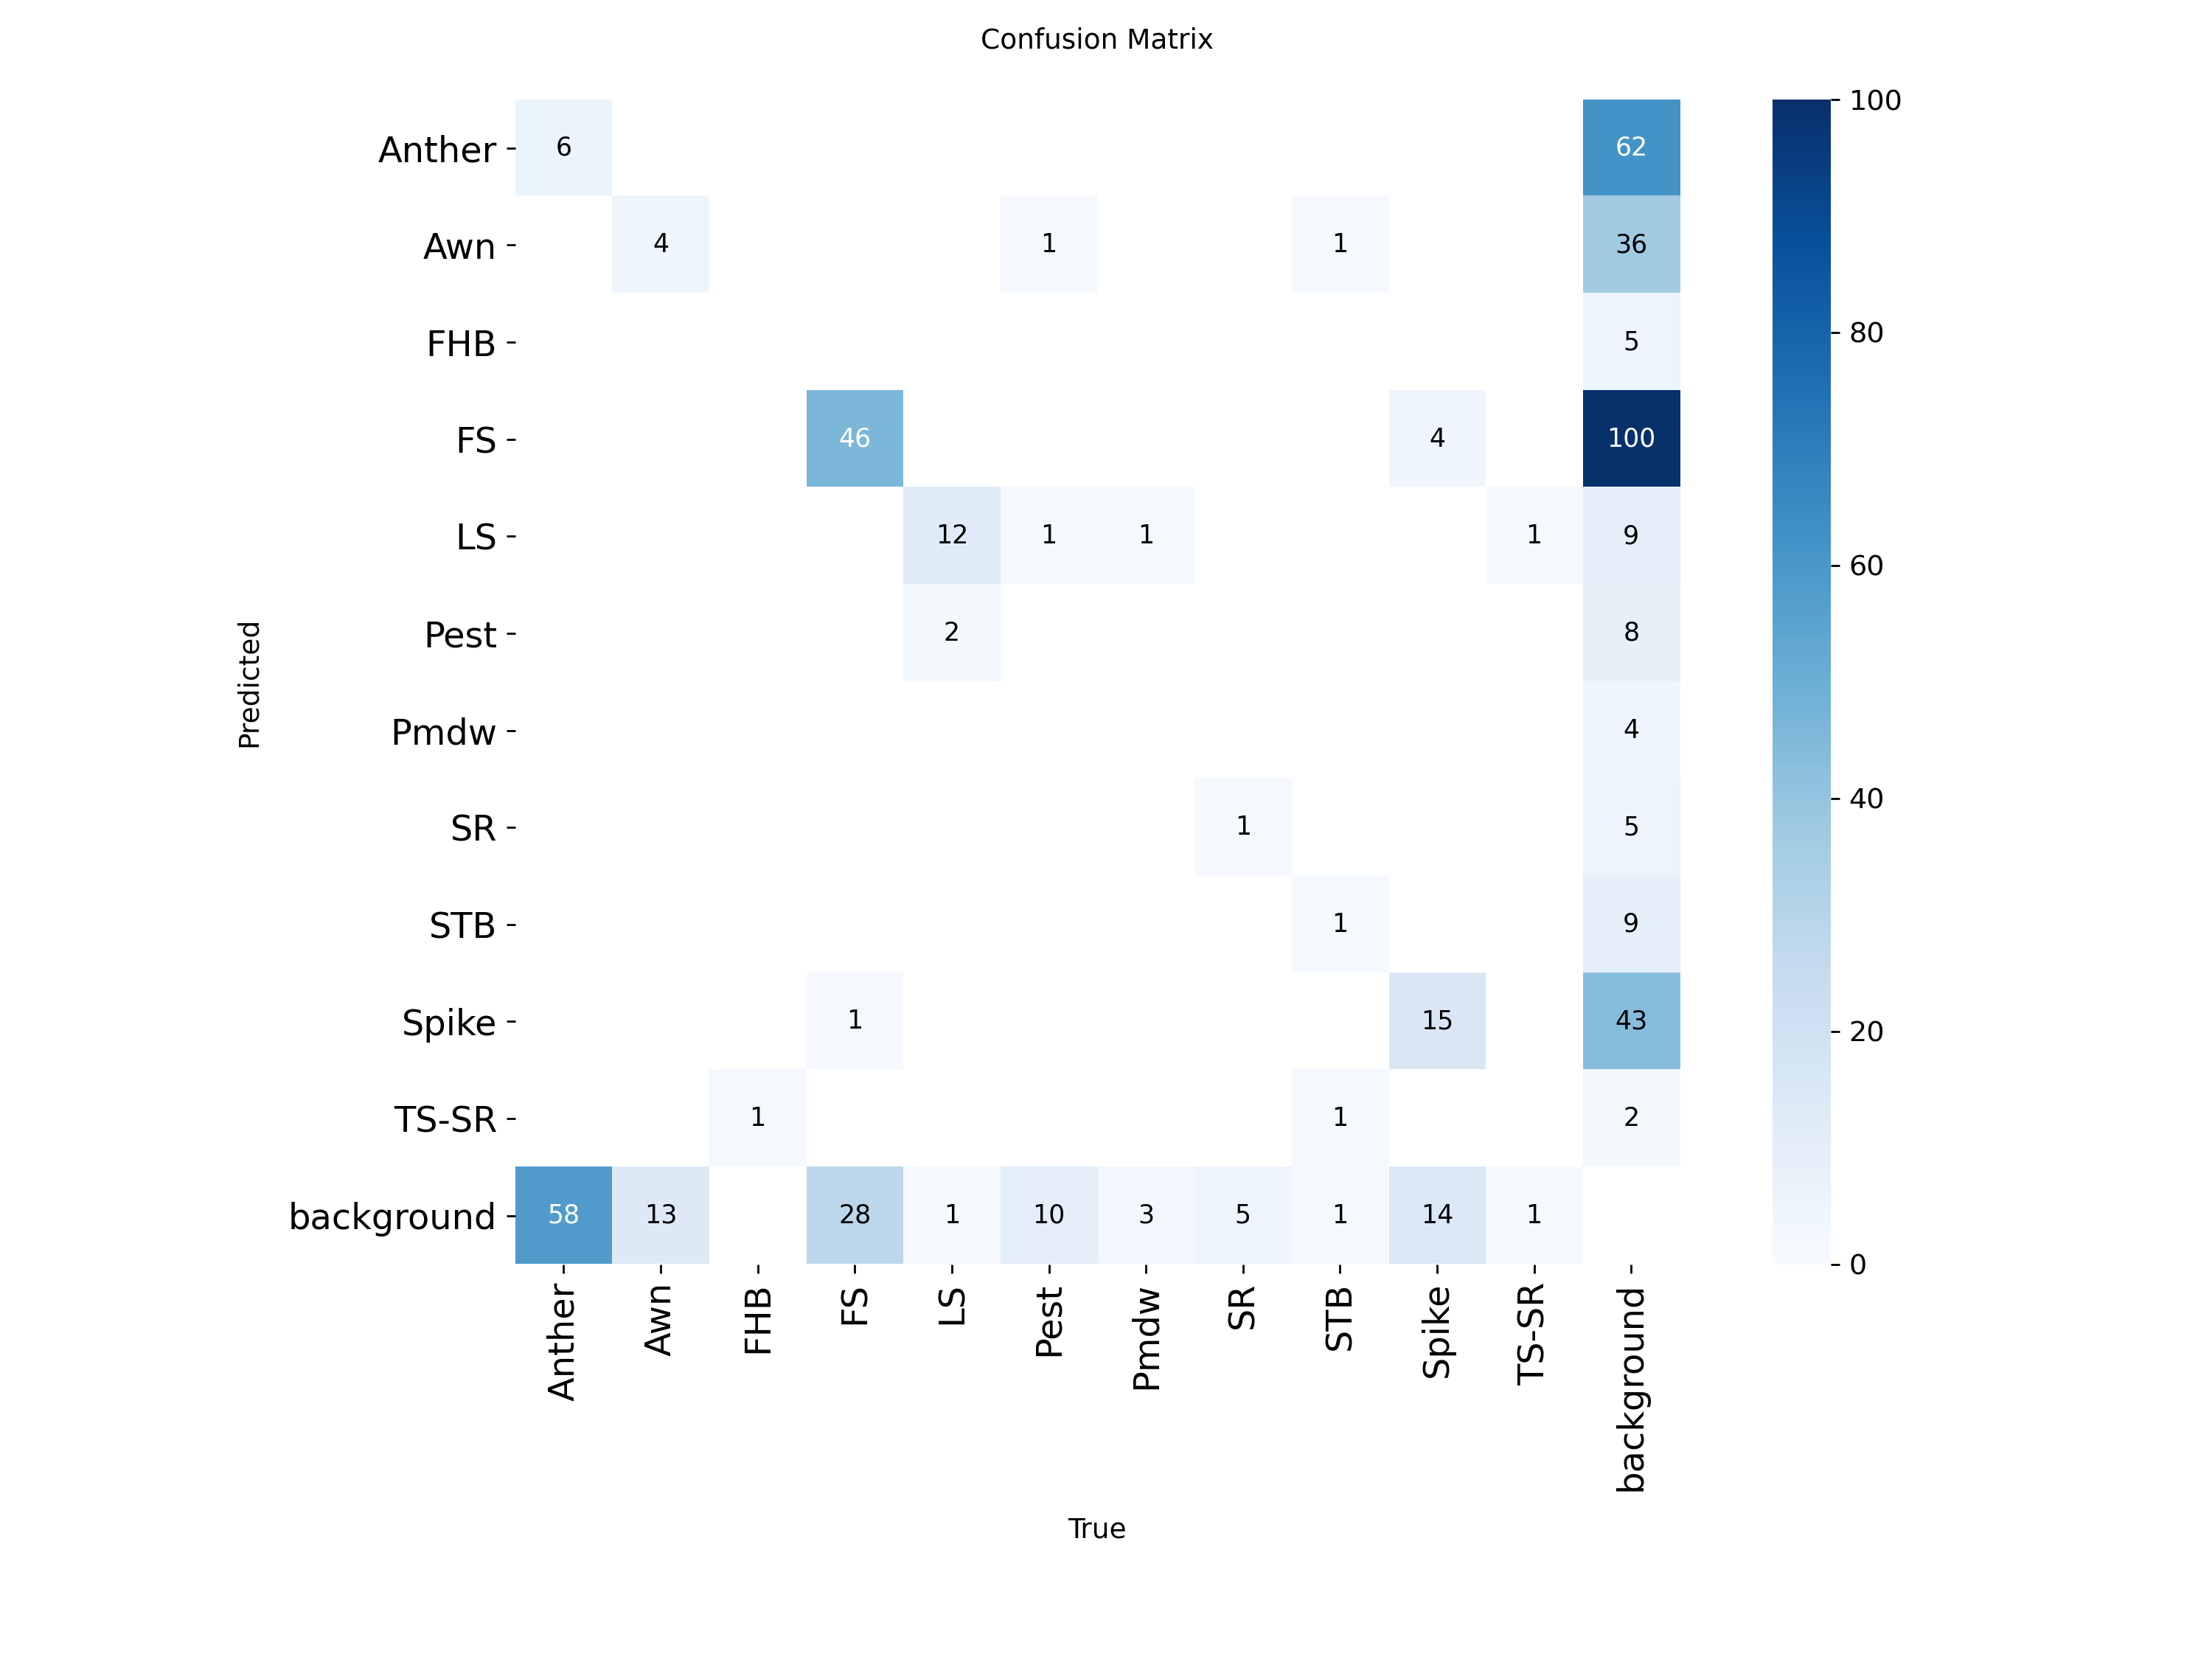

In [10]:
Image ("/content/runs/detect/train/confusion_matrix.png", width= 900)

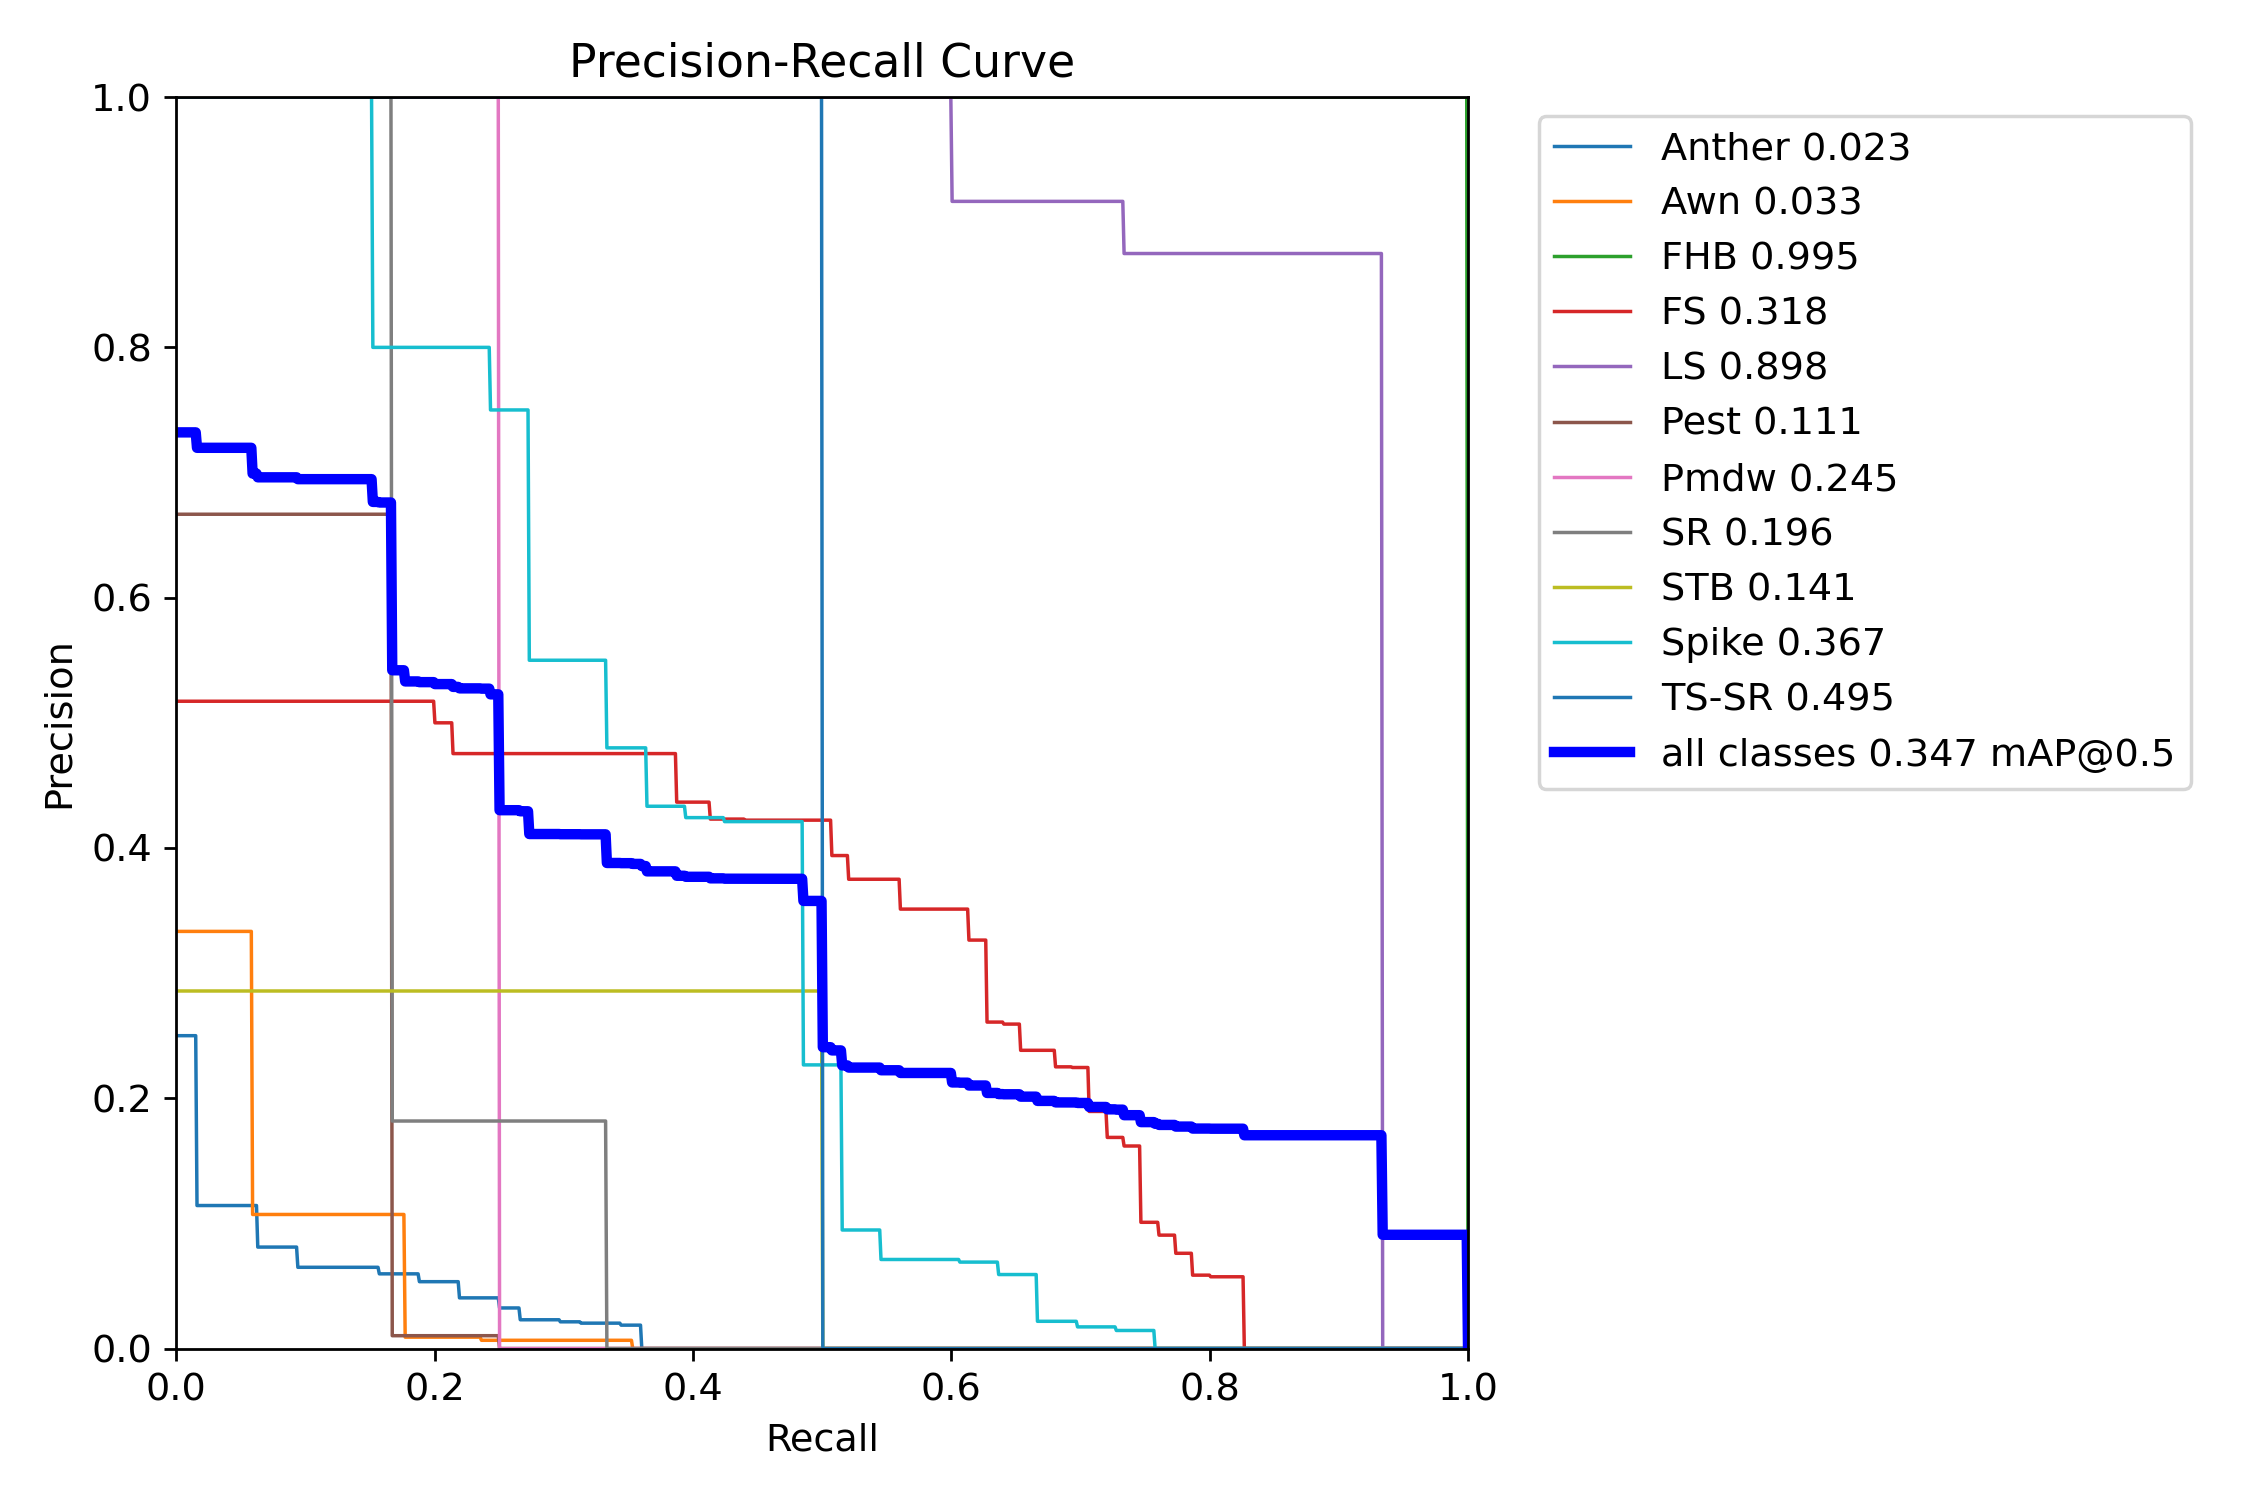

In [11]:
Image ("/content/runs/detect/train/BoxPR_curve.png", width= 900)

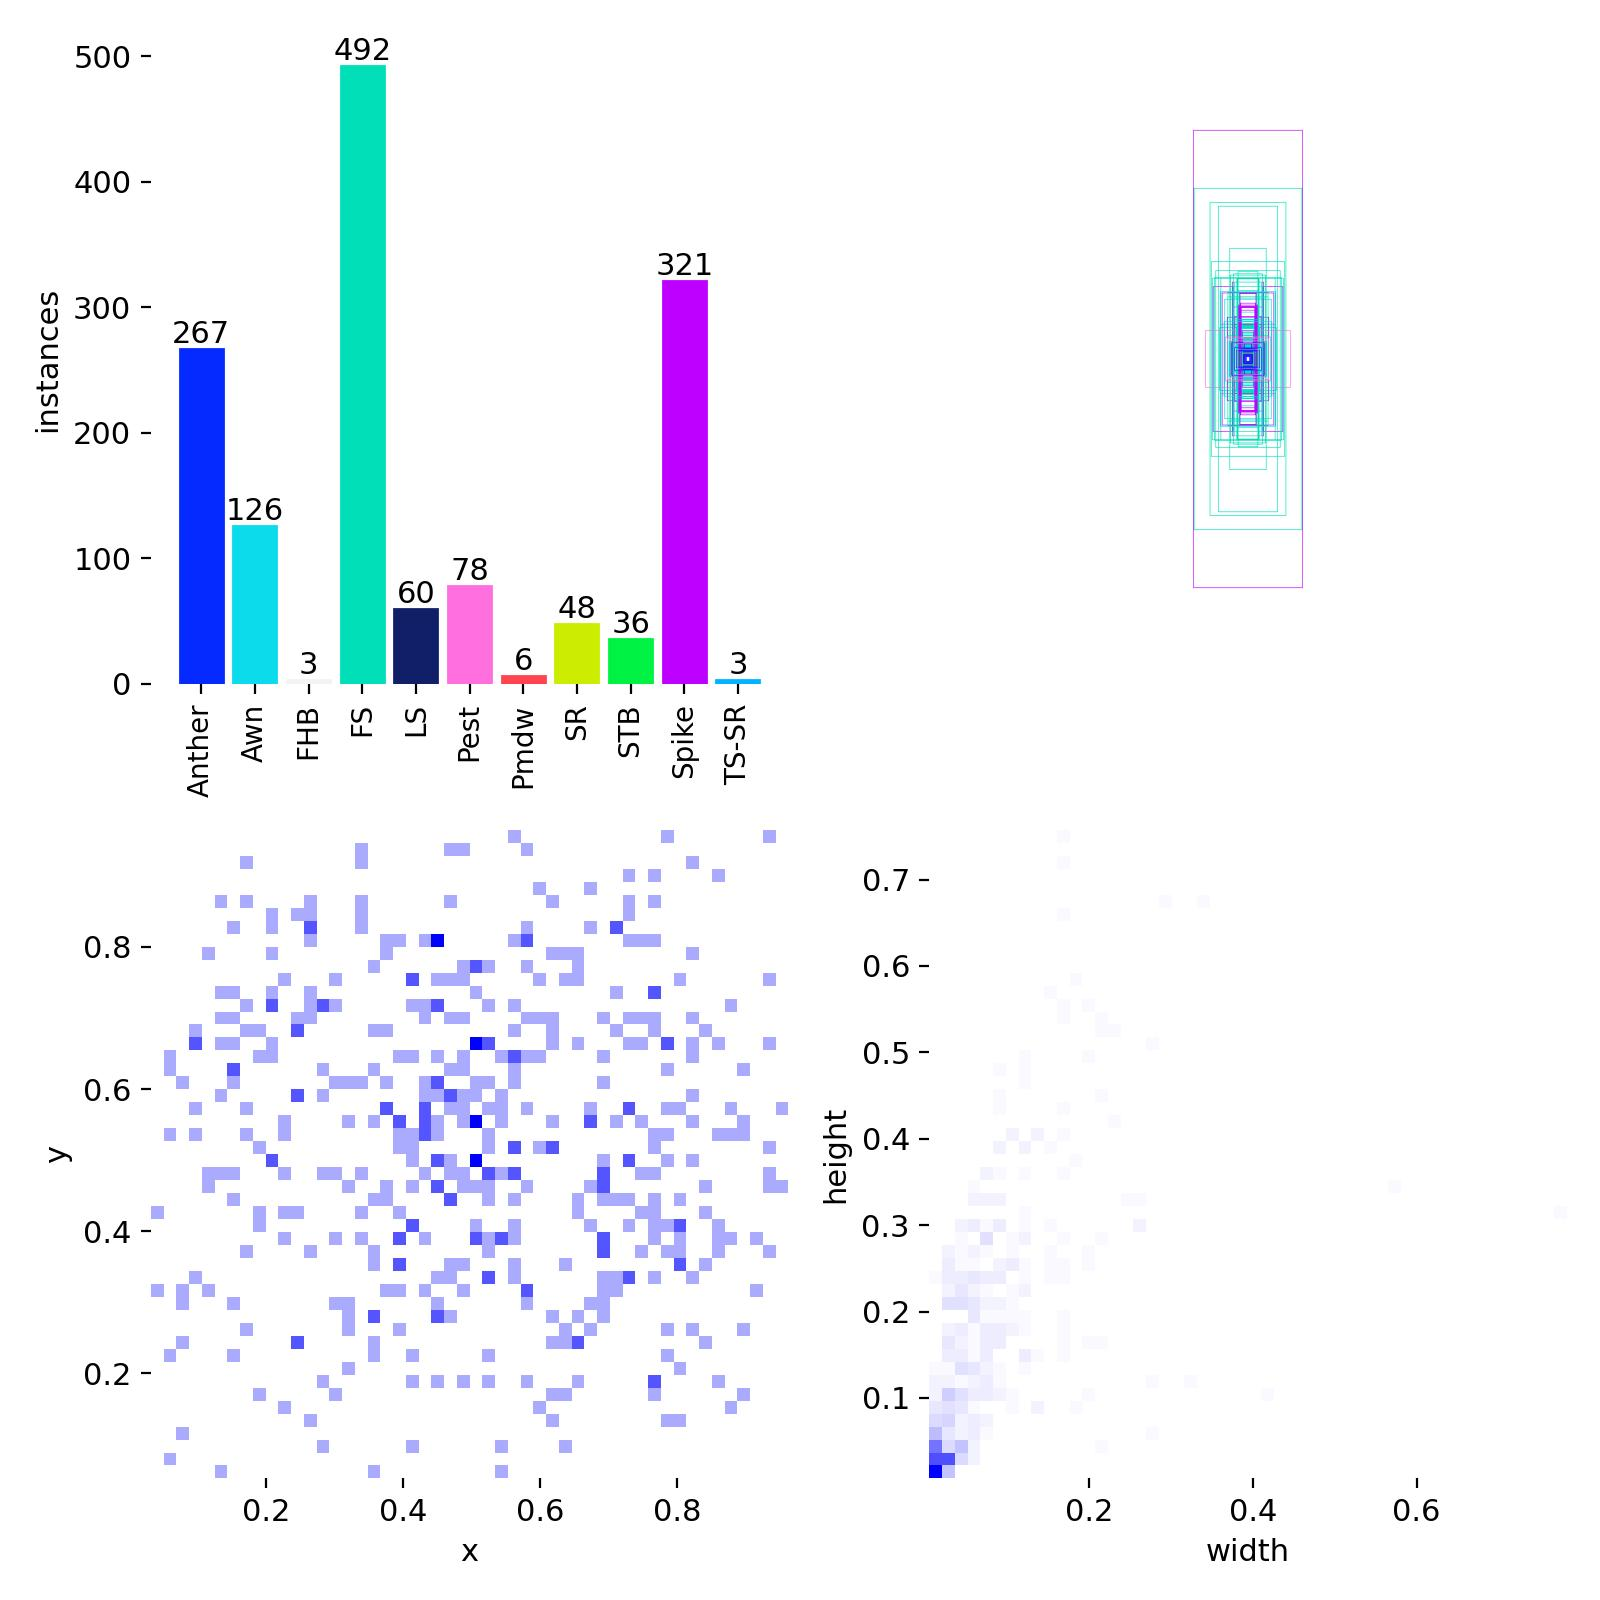

In [12]:
Image ("/content/runs/detect/train/labels.jpg", width= 900)

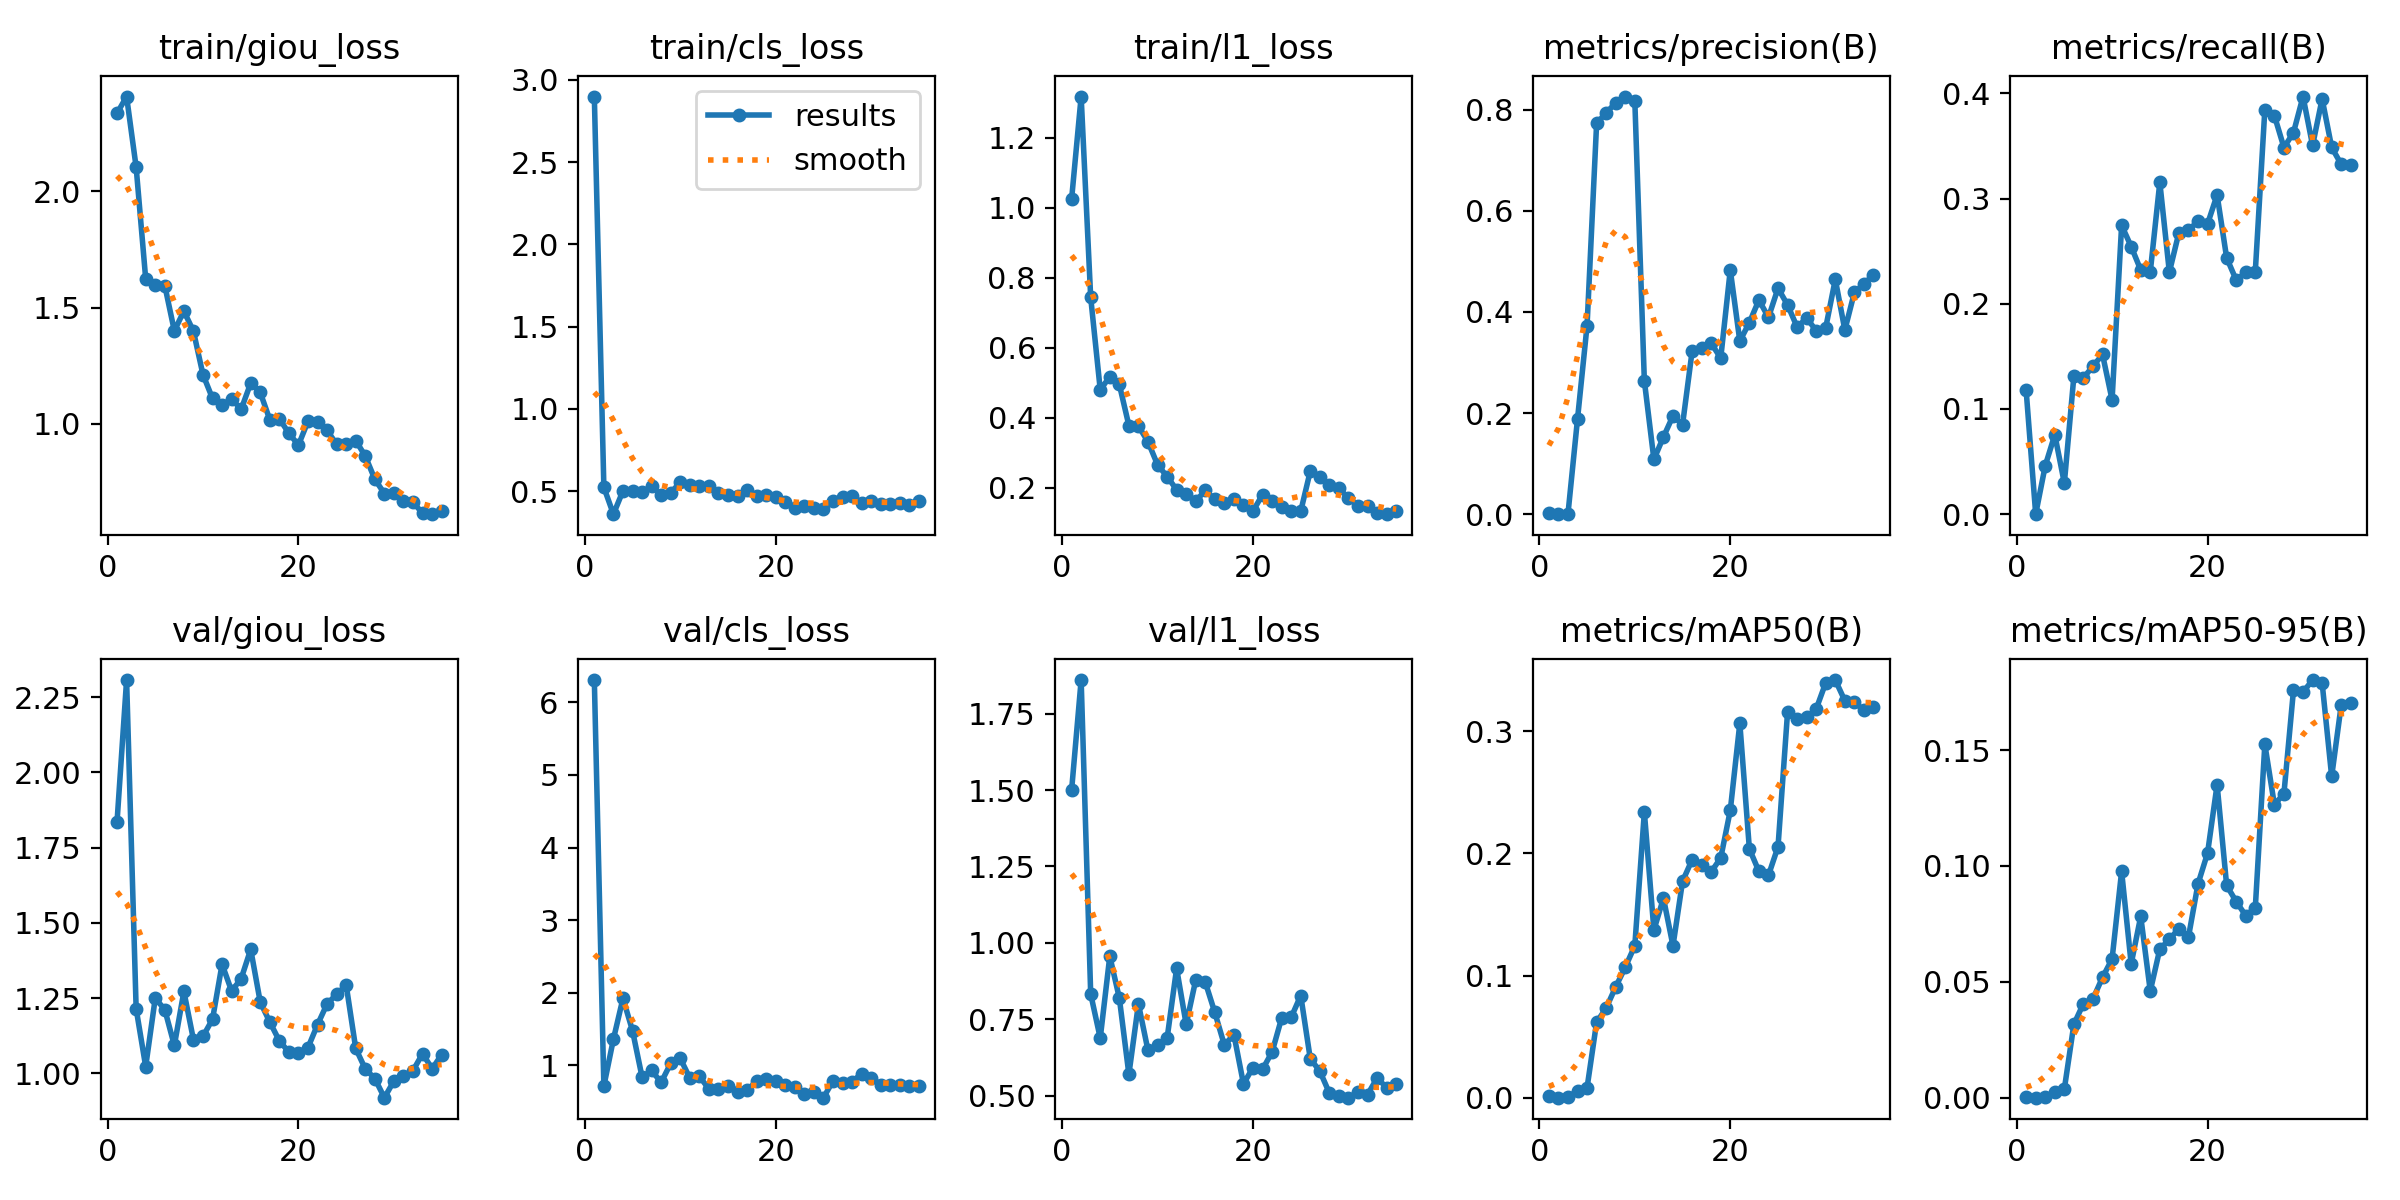

In [13]:
Image ("/content/runs/detect/train/results.png", width= 900)

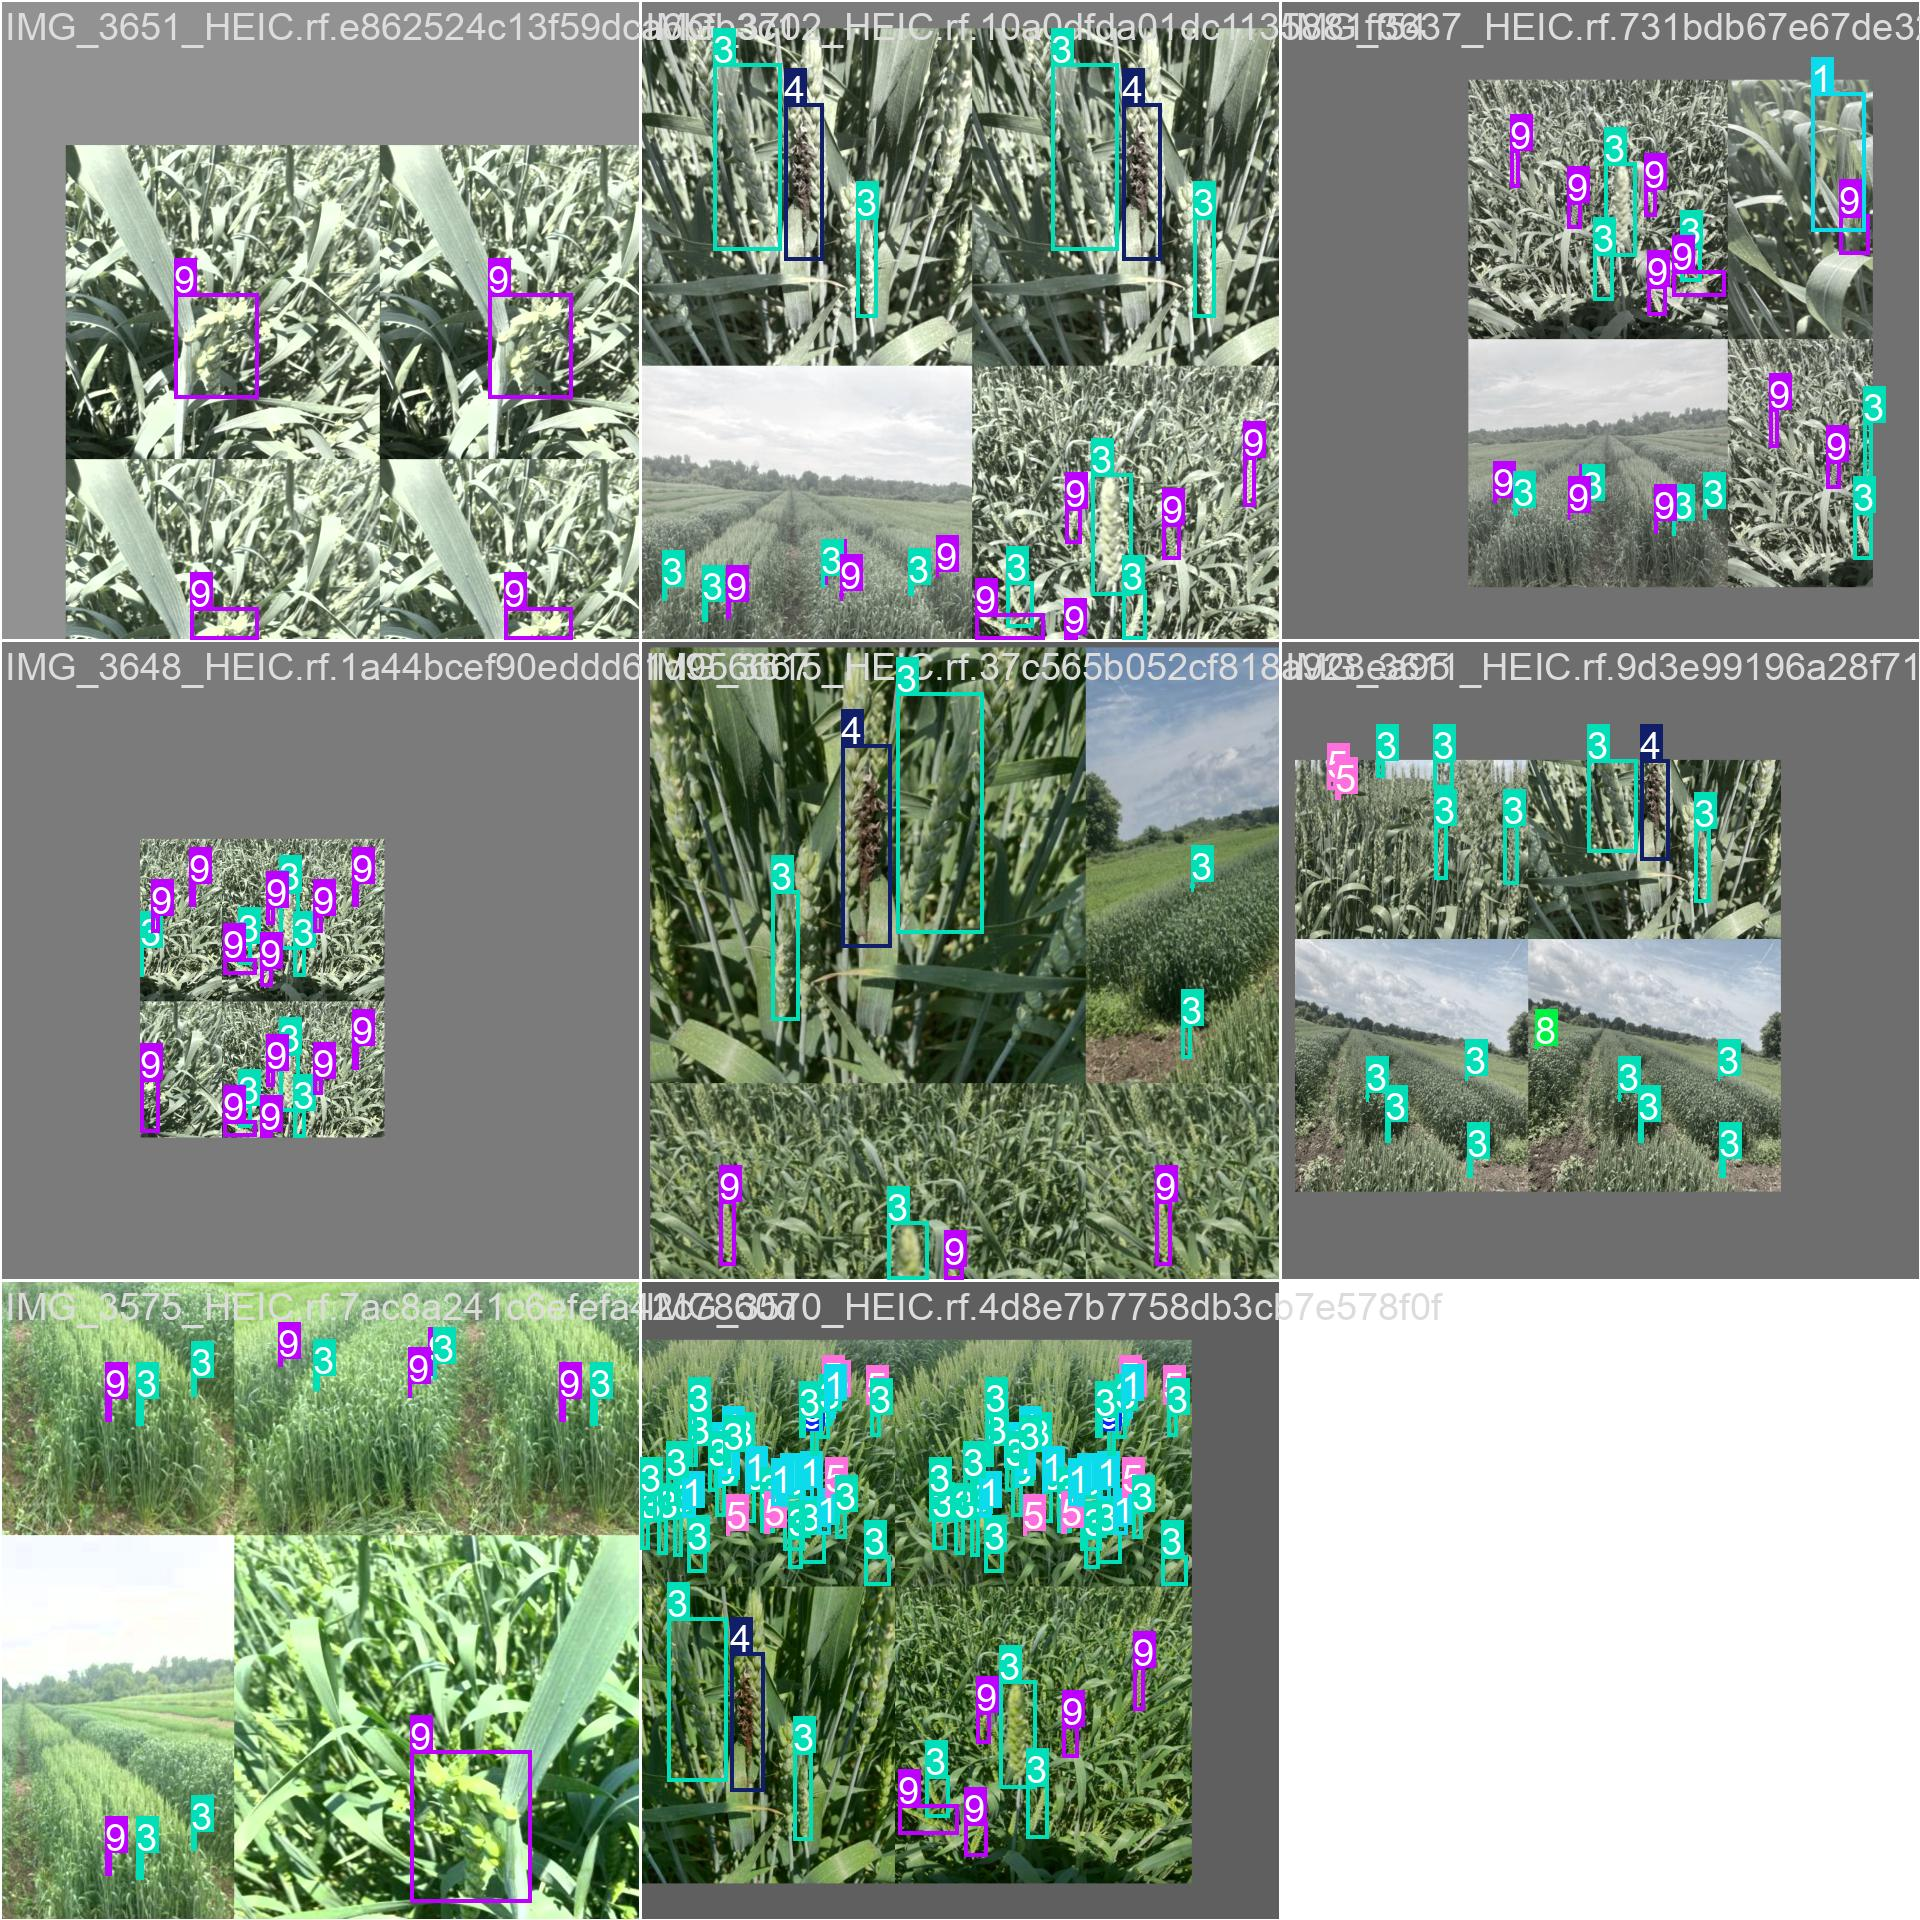

In [15]:
Image ("/content/runs/detect/train/train_batch1.jpg", width= 900)

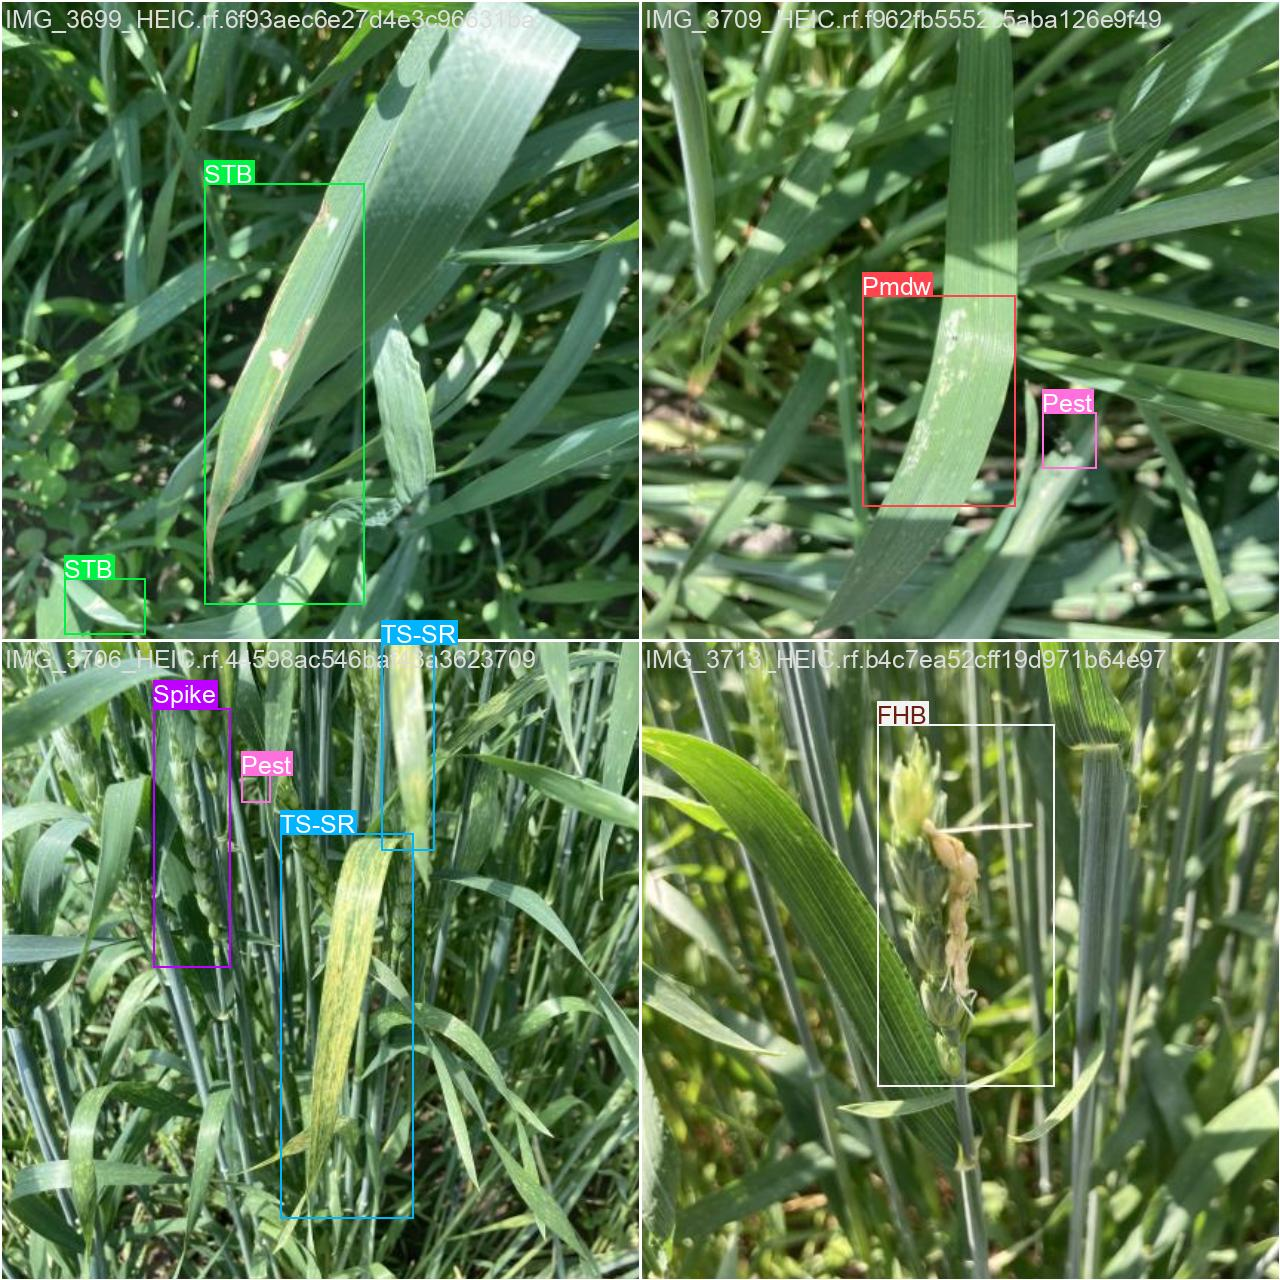

In [16]:
Image ("/content/runs/detect/train/val_batch1_labels.jpg", width= 900)

In [18]:
! yolo task=detect mode=val model="/content/runs/detect/train/weights/best.pt" data={dataset.location}/data.yaml

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
rt-detr-l summary: 310 layers, 32,006,345 parameters, 0 gradients, 103.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1684.2±746.7 MB/s, size: 41.4 KB)
val: Scanning /content/MGP-flowering-3/valid/labels.cache... 36 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 36/36 6.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.9it/s 1.6s
                   all         36        233      0.464       0.35      0.342       0.18
                Anther         11         64     0.0912     0.0156     0.0232    0.00953
                   Awn         10         17     0.0662     0.0588     0.0329    0.00543
                   FHB          1          1      0.879          1      0.995      0.597
                    FS         20         75      0.414      0.452      0.319      0.179
                    LS          9         15  

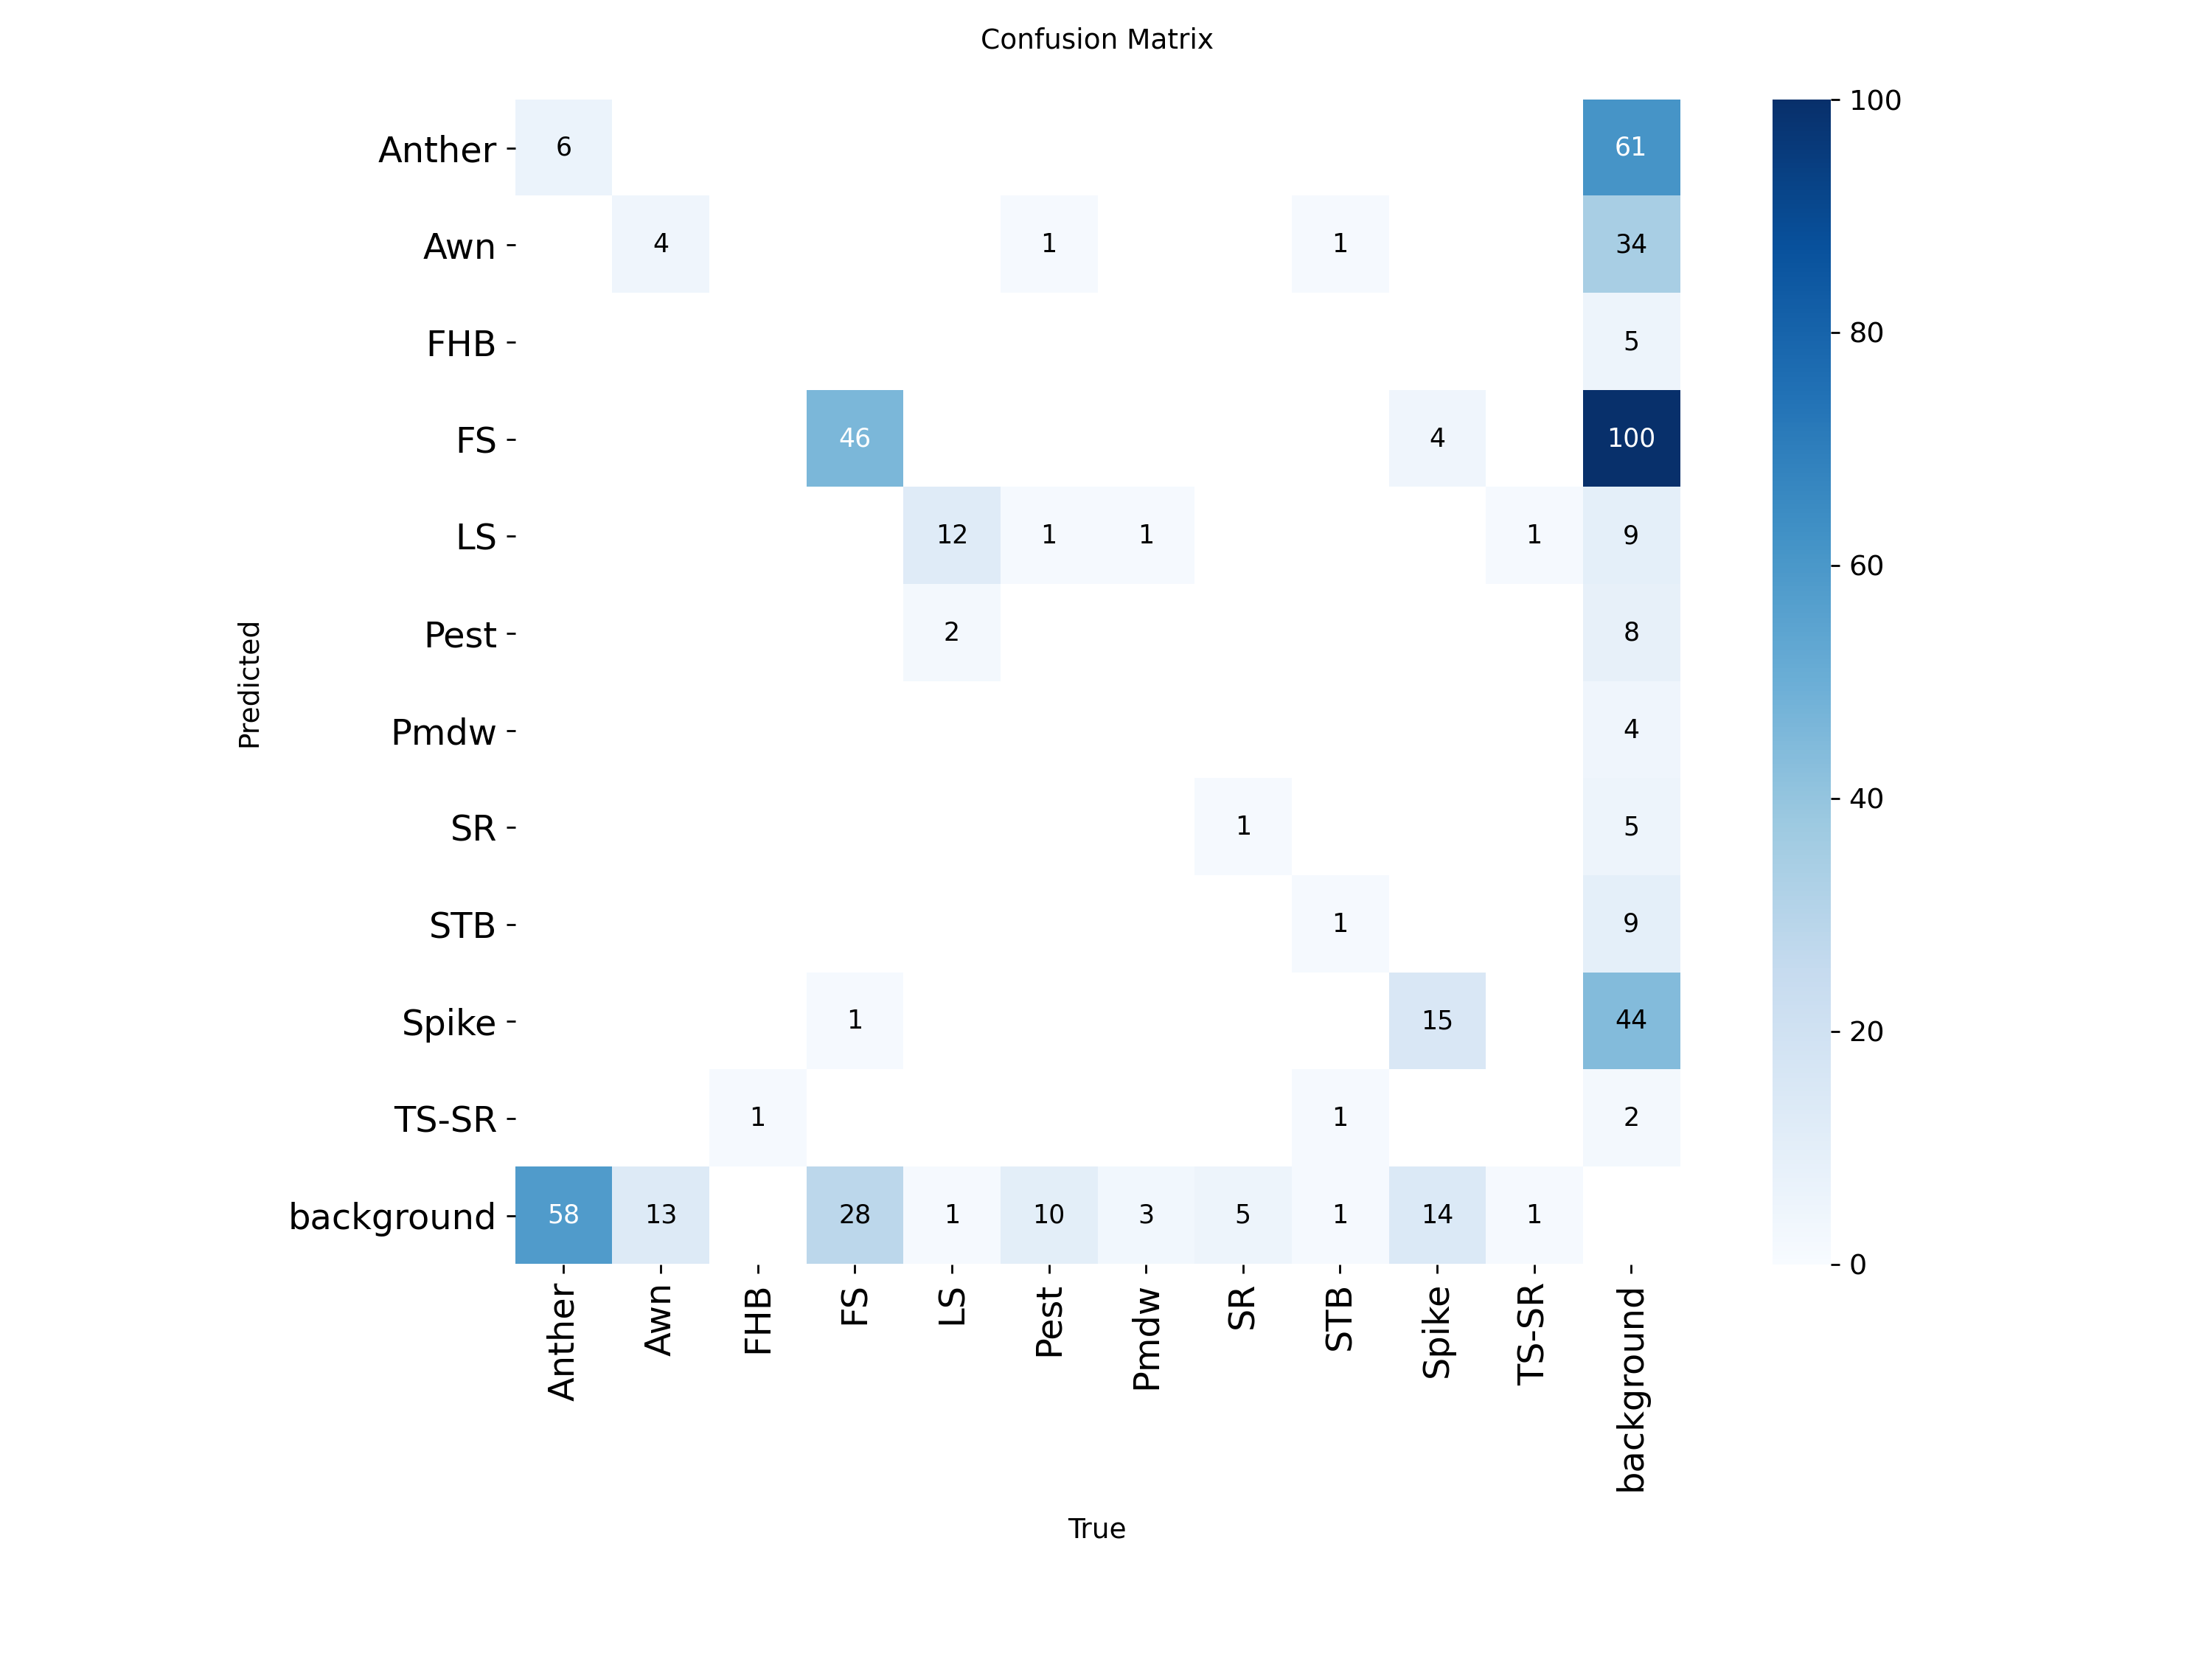

In [19]:
Image ("/content/runs/detect/val/confusion_matrix.png", width= 900)

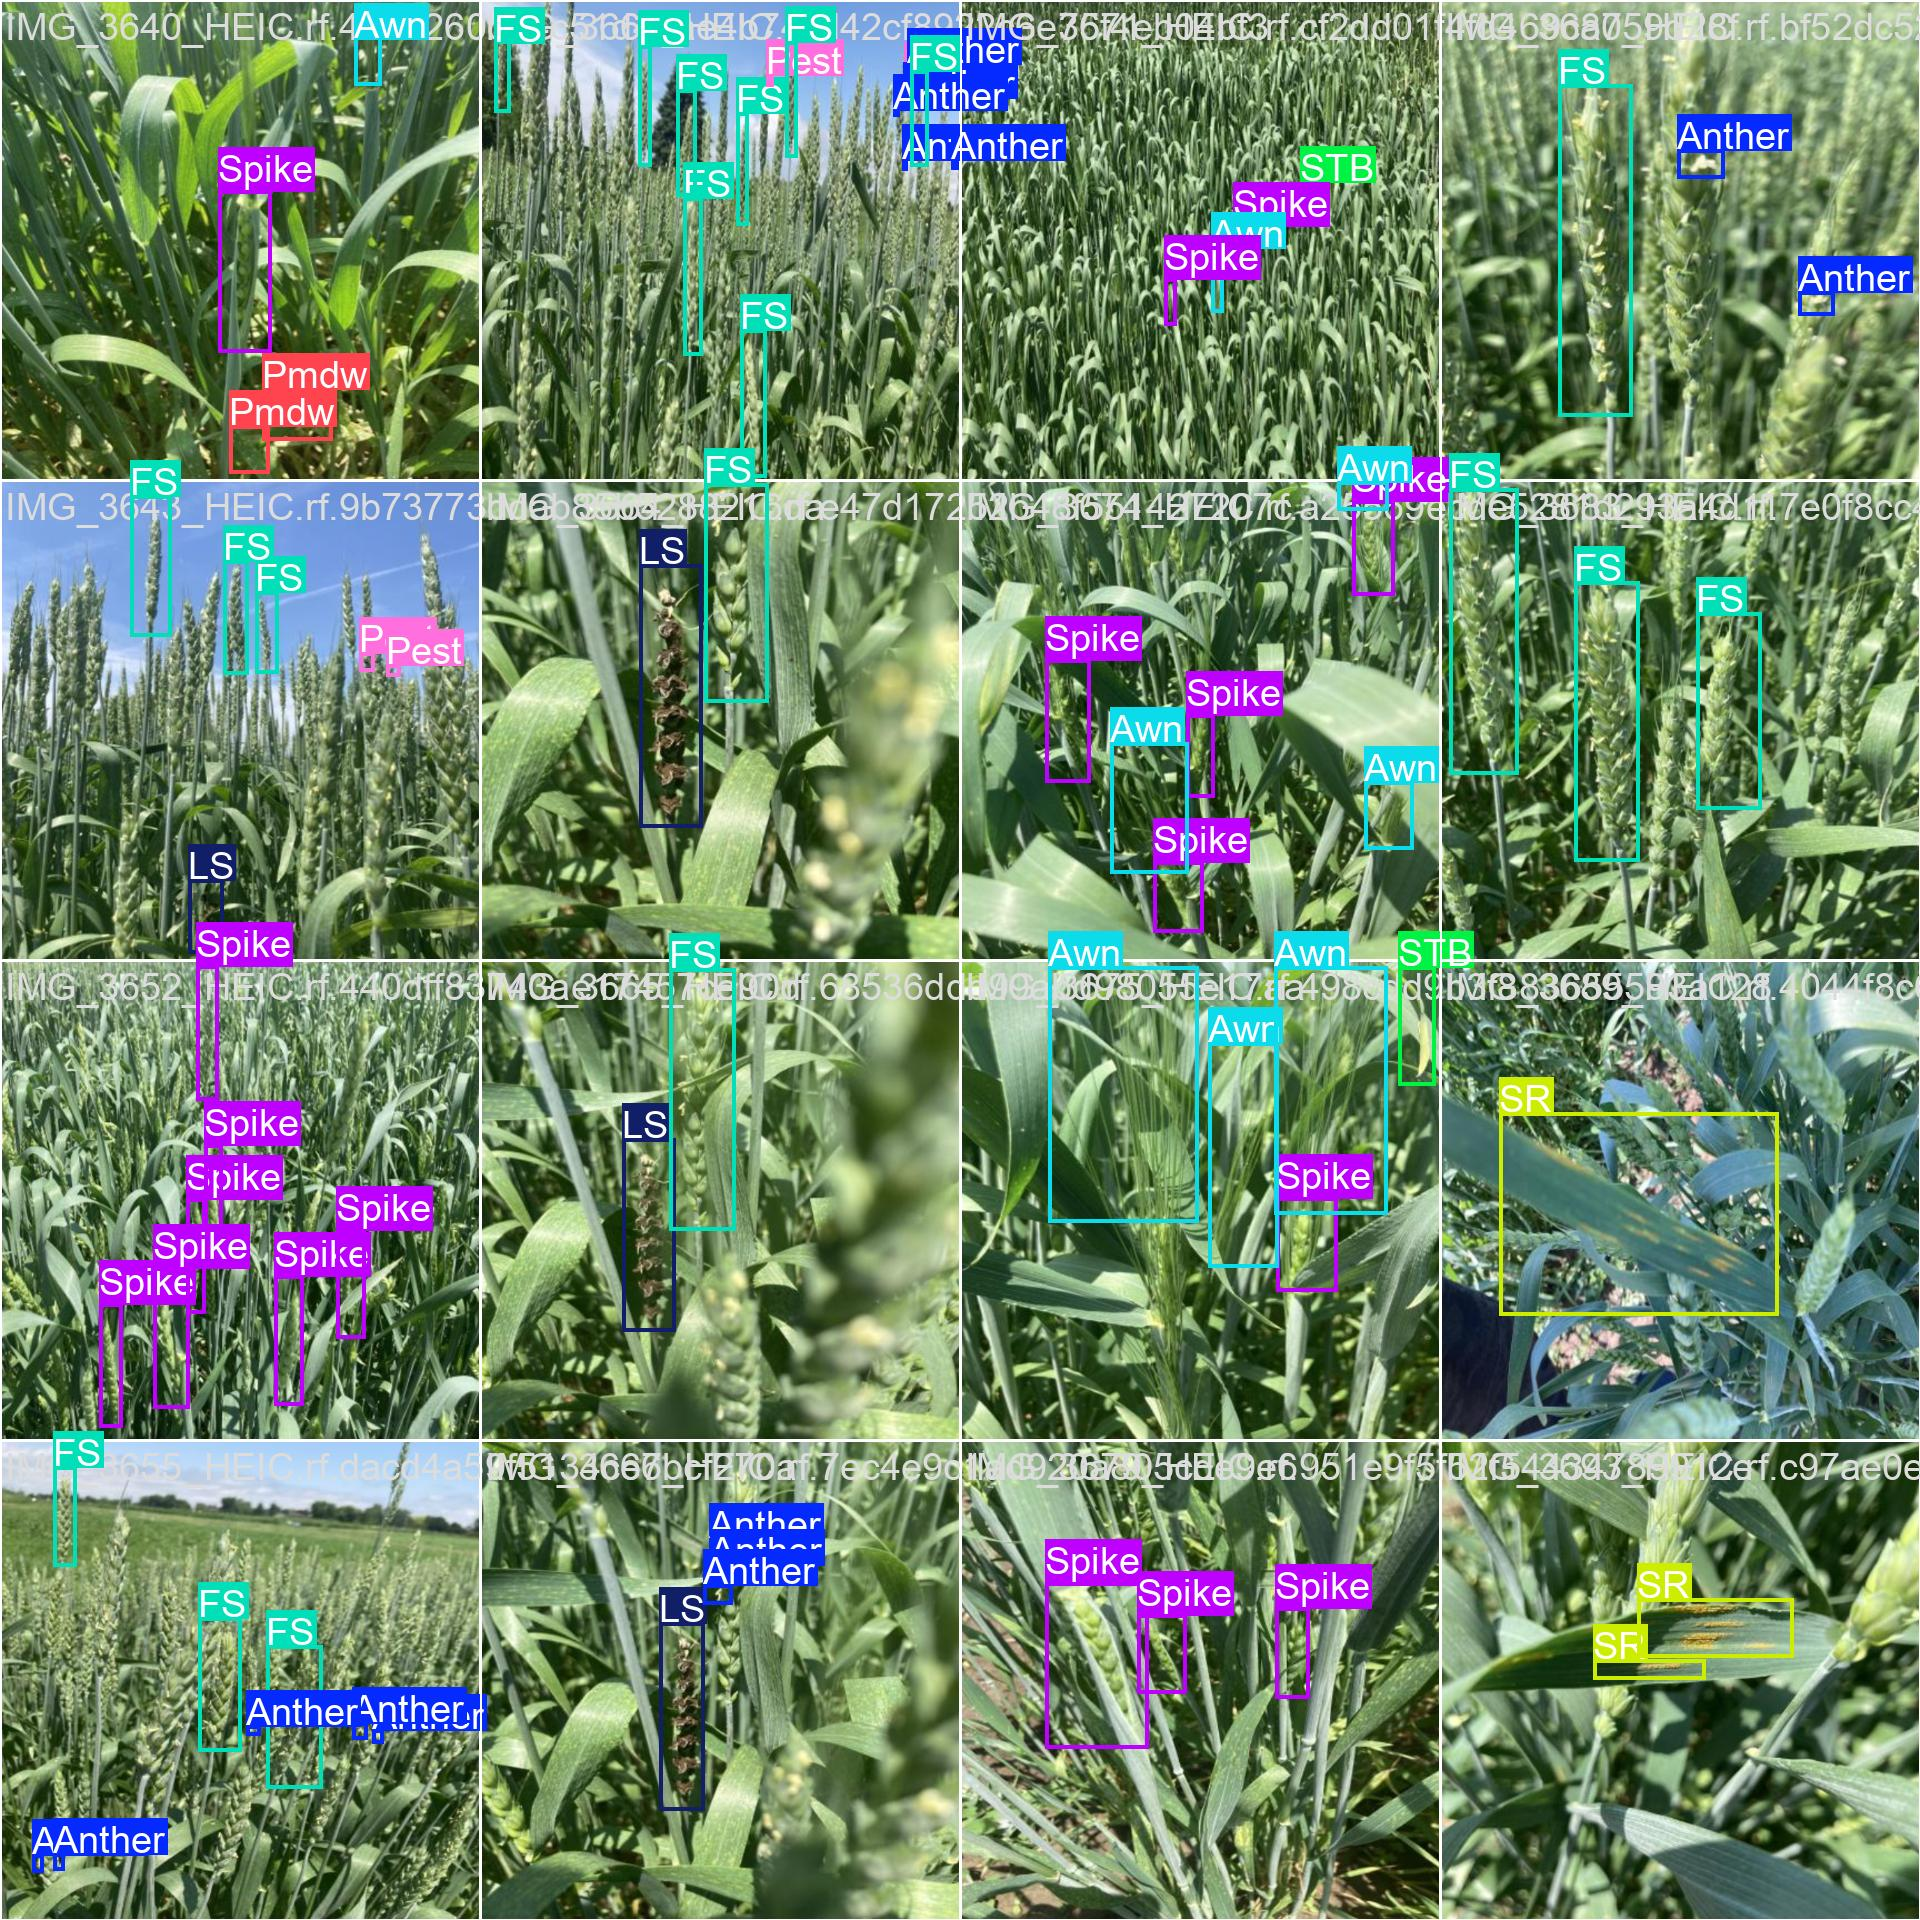

In [20]:
Image ("/content/runs/detect/val/val_batch1_labels.jpg", width= 900)

In [21]:
! yolo task=detect mode=predict model="/content/runs/detect/train/weights/best.pt" conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
rt-detr-l summary: 310 layers, 32,006,345 parameters, 0 gradients, 103.5 GFLOPs

image 1/29 /content/MGP-flowering-3/test/images/IMG_3571_HEIC.rf.bb459efdc7b5b1f835033a1f623127ad.jpg: 640x640 4 Awns, 1 Pest, 3 STBs, 2 Spikes, 43.3ms
image 2/29 /content/MGP-flowering-3/test/images/IMG_3578_HEIC.rf.1dbbbb49fd69064c36372dd2ae44950f.jpg: 640x640 12 Anthers, 3 Awns, 3 FSs, 6 Spikes, 40.9ms
image 3/29 /content/MGP-flowering-3/test/images/IMG_3579_HEIC.rf.9ed58d03ac330e4f2e0ab8344942f3e1.jpg: 640x640 6 Anthers, 3 Awns, 3 FSs, 3 Spikes, 40.7ms
image 4/29 /content/MGP-flowering-3/test/images/IMG_3586_HEIC.rf.6e502e84fef640d8e2c8acc396b272b6.jpg: 640x640 1 Awn, 1 SR, 2 Spikes, 40.9ms
image 5/29 /content/MGP-flowering-3/test/images/IMG_3590_HEIC.rf.0c46fddfc4d697929b022745565bb258.jpg: 640x640 1 Anther, 1 Awn, 5 FSs, 1 SR, 2 Spikes, 42.1ms
image 6/29 /content/MGP-flowering-3/test/images/IMG_3591_HEIC.rf.45a024a4ee

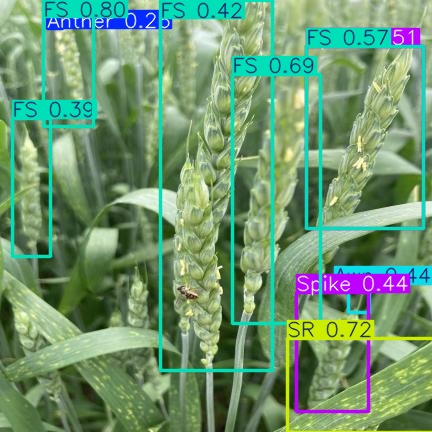

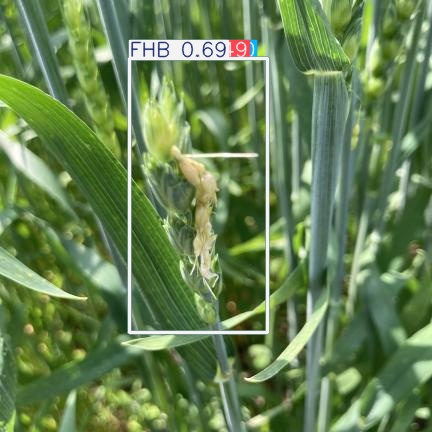

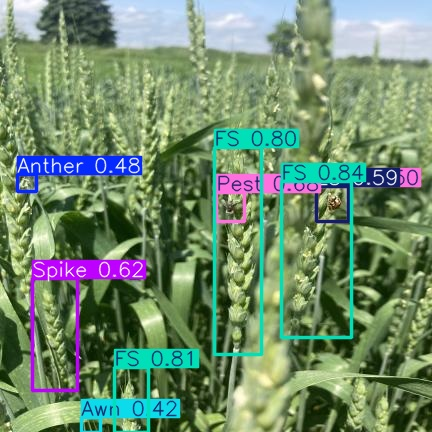

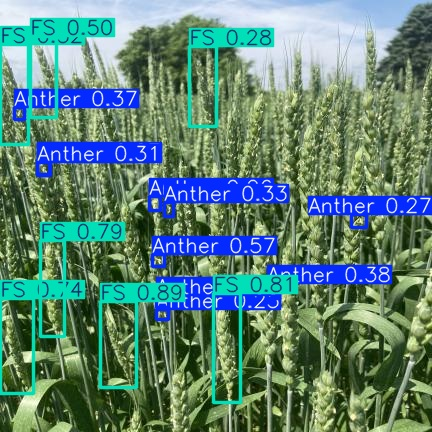

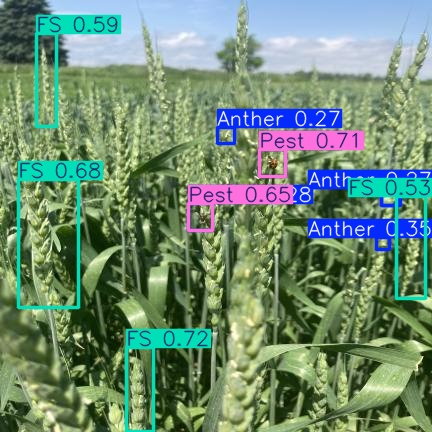

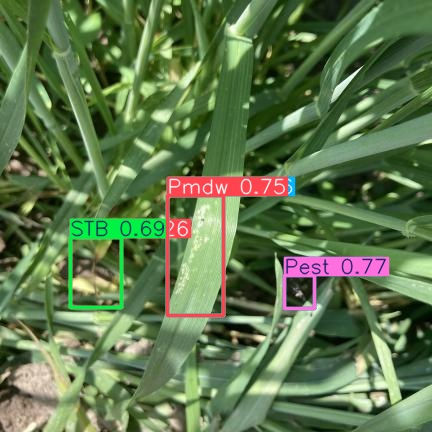

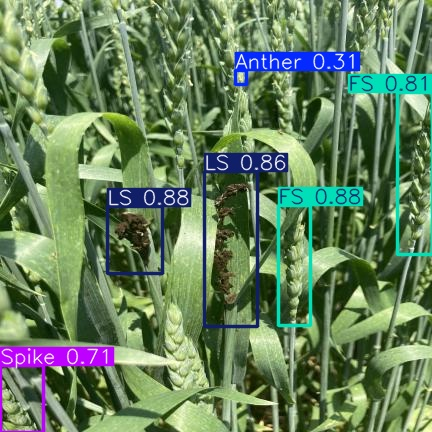

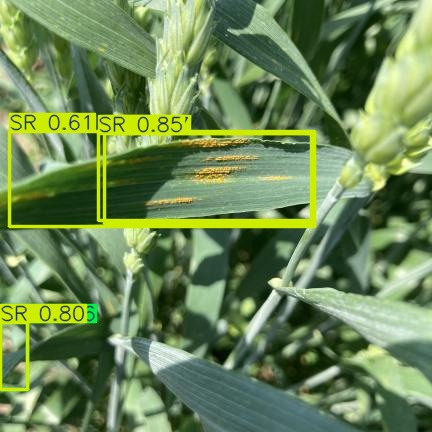

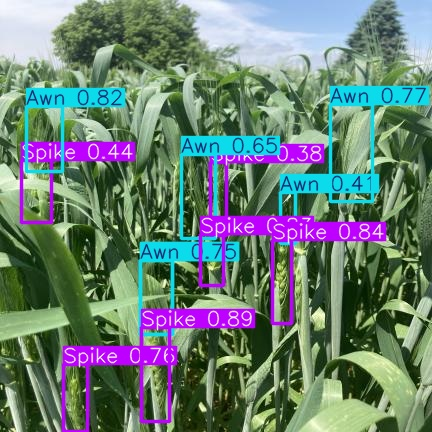

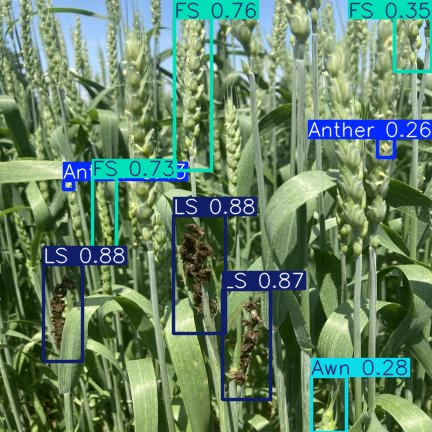

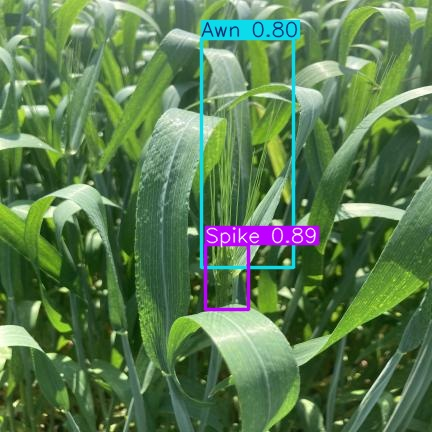

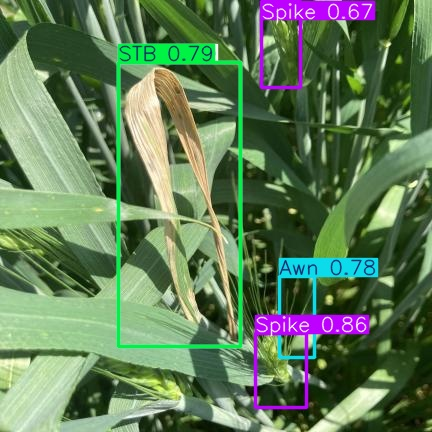

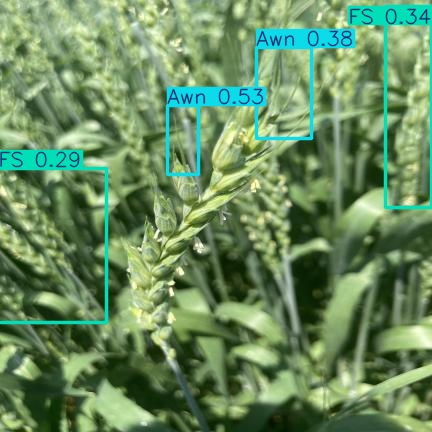

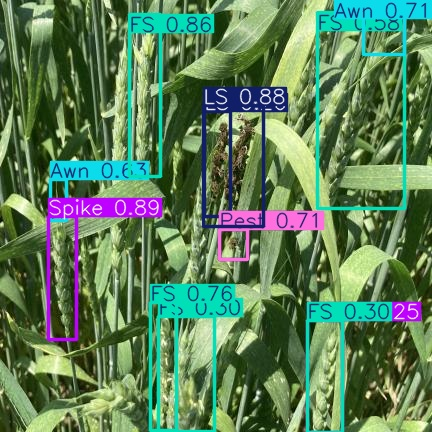

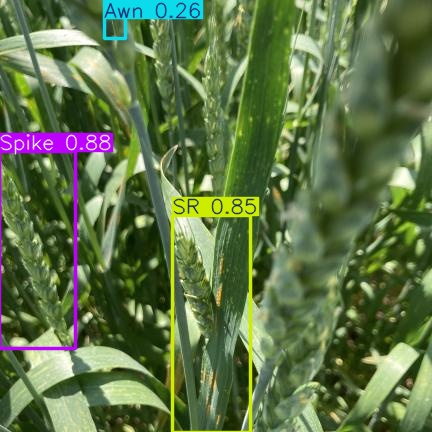

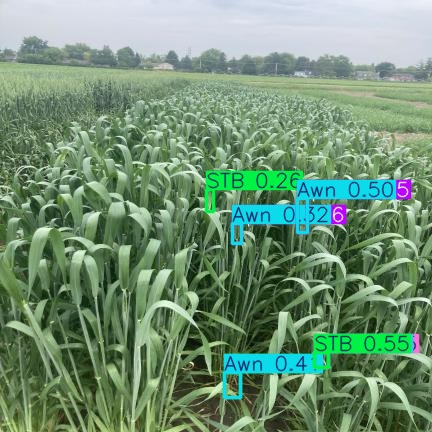

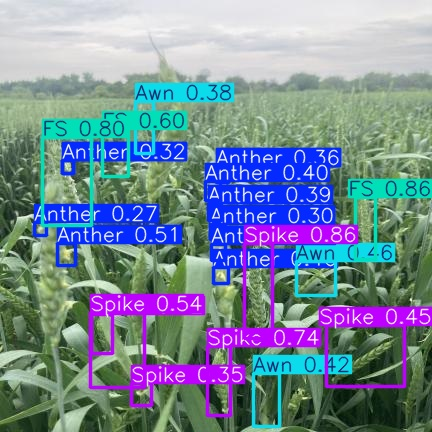

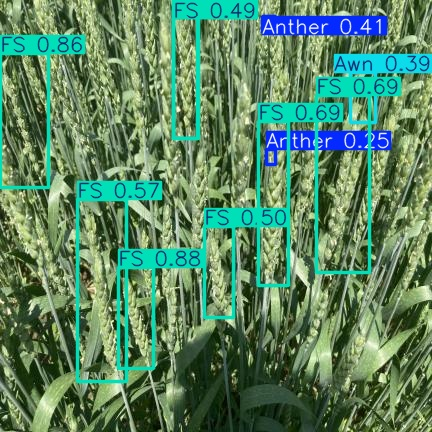

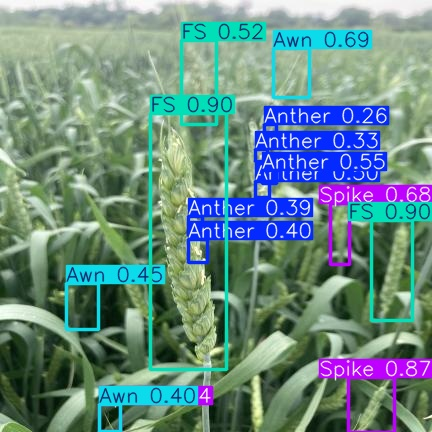

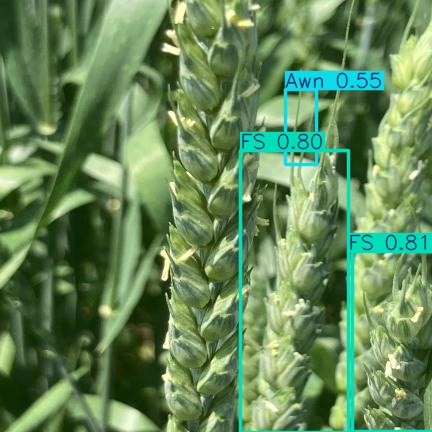

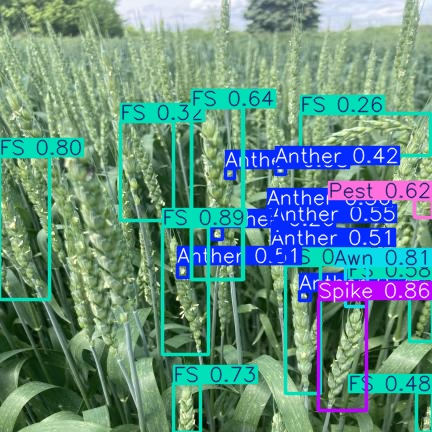

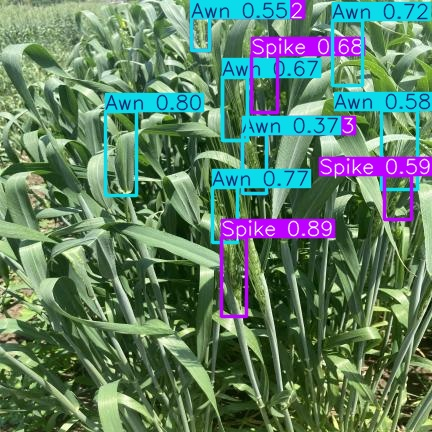

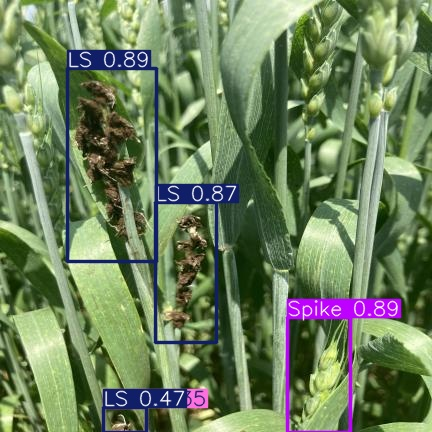

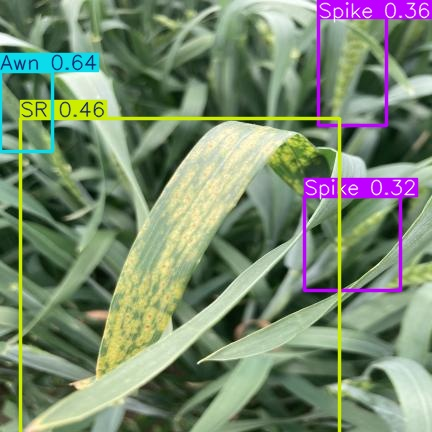

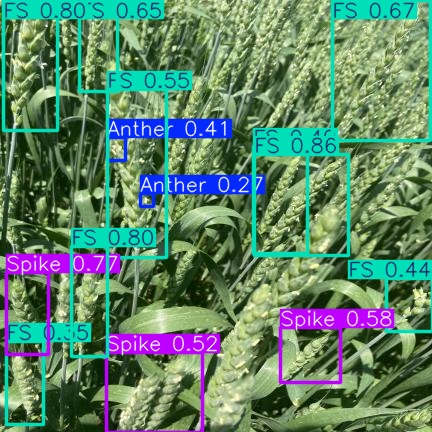

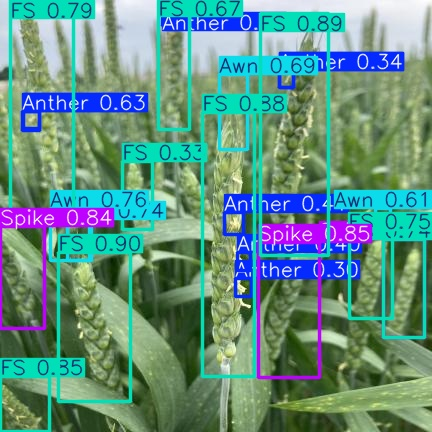

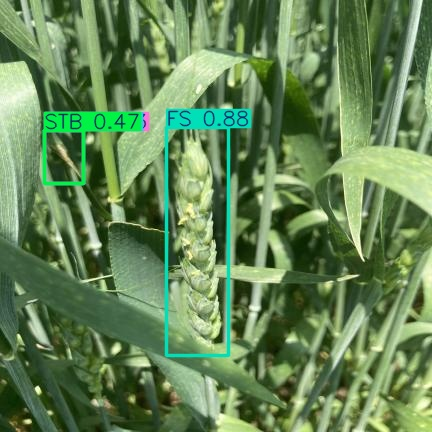

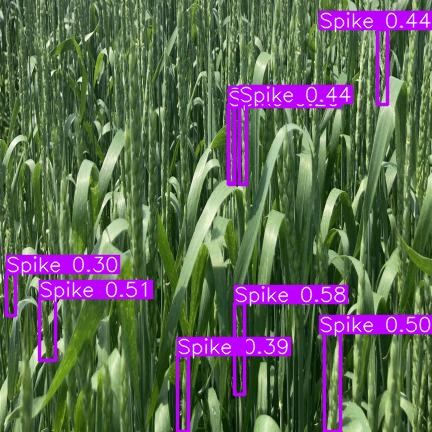

In [22]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob('/content/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[1:30]:
  display(IPyImage(filename=img, width=600))
  print("\n")